# Word Embedding

Tugas keempat berpindah dari representasi kata yang setiap kata menempati posisi
sendiri (sparse) menuju vektor padat yang menangkap kemiripan makna antar kata.
Vektor diambil langsung dari model skip-gram lalu dipakai sebagai fitur
klasifikasi berita sport dan finance, tanpa perantara reduksi dimensi.

## Data Import

Data yang dipakai sama seperti tugas sebelumnya, yaitu hasil crawl detik.com
yang disimpan sebagai CSV. Kolom `isi_berita` menjadi sumber teks dan kolom
`label` menjadi kelas yang diprediksi.

In [1]:
import itertools
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from matplotlib.patches import Patch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings("ignore")

DATA = "../../data/Web-Mining"
df = pd.read_csv(f"{DATA}/crawling_detik.csv")
pd.Series({
    "jumlah berita": len(df),
    "sport": (df["label"] == "sport").sum(),
    "finance": (df["label"] == "finance").sum(),
    "rata-rata karakter": round(df["isi_berita"].str.len().mean(), 1),
}, name="ringkasan korpus")

jumlah berita          200.0
sport                  100.0
finance                100.0
rata-rata karakter    2692.5
Name: ringkasan korpus, dtype: float64

## Train Test Split

Pembagian data dilakukan **sebelum** pelatihan model apa pun, termasuk sebelum
skip-gram dilatih. Kalau vektor kata dilatih pada seluruh korpus, teks uji ikut
menyumbang kata dan statistik yang membuat skor klasifikasi terlalu optimistis.
Bagian yang diuji harus benar-benar data yang belum pernah dilihat model.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    df["isi_berita"], df["label"], test_size=0.2, stratify=df["label"], random_state=42
)
pd.Series({
    "data latih": len(X_train),
    "data uji": len(X_test),
    "kelas latih": dict(y_train.value_counts()),
    "kelas uji": dict(y_test.value_counts()),
}, name="hasil pembagian")

data latih                              160
data uji                                 40
kelas latih    {'finance': 80, 'sport': 80}
kelas uji      {'finance': 20, 'sport': 20}
Name: hasil pembagian, dtype: object

## Text Preprocessing

Empat preprocessing disiapkan sebagai sakelar agar pengaruh tiap komponen bisa
diukur sendiri-sendiri. Tiap sakelar bernilai benar kalau langkahnya dijalankan:

- **stopword** — buang stopword Indonesia dari Sastrawi.
- **tanda baca** — buang, atau pertahankan sebagai token sendiri.
- **slang** — petakan bentuk tidak baku ke bentuk baku.
- **stemming** — ambil akar kata dengan Sastrawi.

Stopword diambil dari kamus bawaan Sastrawi agar daftarnya sama dengan yang
dipakai pada tugas sebelumnya. Daftar slang tidak ditebak: kandidatnya dihitung
dulu dari frekuensi korpus, lalu setiap kandidat diperiksa pada konteksnya.

In [3]:
frekuensi = pd.Series(
    [w for t in df["isi_berita"] for w in re.findall(r"[a-z]+", t.lower())]
).value_counts()

kandidat = ["nggak", "bikin", "gas", "sih", "aja", "yuk", "guna", "udah", "gw",
            "gue", "banget", "kalo", "dapet", "pake", "lo", "dr", "mantap", "keren"]
pd.DataFrame(
    {"frekuensi": [frekuensi.get(k, 0) for k in kandidat]},
    index=kandidat,
).sort_values("frekuensi", ascending=False)

,frekuensi
nggak,36
bikin,22
gas,14
guna,11
sih,9
aja,7
yuk,6
banget,6
gw,3
udah,3


Hasil pemeriksaan konteks mengubah beberapa dugaan awal:

| Bentuk | Frekuensi | Keputusan | Alasan |
|---|---|---|---|
| `nggak` | 36 | **diterjemahkan** → `tidak` | satu makna, selalu penanda negasi |
| `bikin` | 22 | **diterjemahkan** → `membuat` | kependekan baku, tidak pernah bermakna lain |
| `gas` | 14 | **dipertahankan** | dua makna: `tancap gas` (kolokial) dan `minyak dan gas` (literal) |
| `sih` | 9 | **dipertahankan** | partikel pengisi, tidak punya padanan tunggal |
| `aja` | 7 | **diterjemahkan** → `saja` | tidak bermakna lain dalam konteks berita |
| `yuk` | 6 | **diterjemahkan** → `ayo` | selalu muncul sebagai ajakan |
| `guna` | 11 | **dipertahankan** | ternyata kata baku, bukan slang |
| `lo` | 1 | **dipertahankan** | muncul sebagai bagian nama orang |
| `dr` | 2 | **diterjemahkan** → `dari` | singkatan umum, tanpa makna lain |

Aturan yang dipakai: bentuk hanya diterjemahkan kalau seluruh kemunculannya
bermakna sama dan punya padanan Indonesia yang wajar. Kalau ragu, bentuk asli
dibiarkan. `gas` dan `lo` menunjukkan kenapa aturan ini perlu: `gas` akan salah
kalau dipaksa menjadi `ayo`, dan `lo` akan merusak nama orang.

In [4]:
SLANG = {
    "nggak": "tidak",
    "bikin": "membuat",
    "aja": "saja",
    "yuk": "ayo",
    "udah": "sudah",
    "gw": "saya",
    "gue": "saya",
    "banget": "sangat",
    "kalo": "kalau",
    "dapet": "dapat",
    "pake": "pakai",
    "dr": "dari",
}

swr = StopWordRemoverFactory().create_stop_word_remover()
STOPWORDS = set(swr.get_dictionary().words)

pd.Series({
    "stopword Sastrawi": len(STOPWORDS),
    "slang diterjemahkan": len(SLANG),
}, name="isi preprocessing")

stopword Sastrawi      123
slang diterjemahkan     12
Name: isi preprocessing, dtype: int64

Stemming Sastrawi berjalan cukup lambat, sekitar 17 milidetik per kata. Kalau
dipanggil ulang untuk tiap kombinasi, biaya itu terulang enam belas kali. Akar
kata karena itu dihitung sekali untuk seluruh kosakata korpus, lalu disimpan
sebagai kamus yang dibaca cepat saat stemming aktif.

In [5]:
kosakata = sorted({w for t in df["isi_berita"] for w in re.findall(r"[a-z]+", t.lower())})
stemmer = StemmerFactory().create_stemmer()

mulai = time.time()
STEM = {w: stemmer.stem(w) for w in kosakata}
durasi = time.time() - mulai

pd.Series({
    "kosakata korpus": len(kosakata),
    "waktu stemming": f"{durasi:.0f} detik",
    "ms per kata": round(durasi / len(kosakata) * 1000, 1),
    "contoh": ", ".join(f"{k}->{STEM[k]}" for k in ["pemain", "membuka", "bertanding", "kemenangan"]
                        if k in STEM),
}, name="kamus akar kata")

kosakata korpus                                                 7544
waktu stemming                                             243 detik
ms per kata                                                     32.2
contoh             pemain->main, membuka->buka, bertanding->tandi...
Name: kamus akar kata, dtype: object

Fungsi `prep` menerapkan keempat sakelar; setiap argumen bernilai benar kalau
langkahnya dijalankan. Urutannya dari yang paling menyaring lebih dulu: tanda
baca dibuang sebelum stopword, dan stemming paling akhir supaya tidak bekerja
pada token yang sudah tidak dipakai.

In [6]:
DENGAN_TANDA_BACA = re.compile(r"[a-z]+|\d+|[^\w\s]")
TANPA_TANDA_BACA = re.compile(r"[a-z]+|\d+")


def prep(text, buang_stopword=True, buang_tanda_baca=False, normalisasi_slang=True, stemming=True):
    pola = TANPA_TANDA_BACA if buang_tanda_baca else DENGAN_TANDA_BACA
    tokens = pola.findall(text.lower())
    if normalisasi_slang:
        tokens = [SLANG.get(t, t) for t in tokens]
    if buang_stopword:
        tokens = [t for t in tokens if t not in STOPWORDS]
    if stemming:
        tokens = [STEM.get(t, t) for t in tokens]
    return tokens


contoh = "Nggak ada yang tau, udah tiga klub bikin tawaran, guys!"
pd.DataFrame(
    {"token": [
        " ".join(prep(contoh)),
        " ".join(prep(contoh, buang_stopword=False, buang_tanda_baca=False,
                      normalisasi_slang=False, stemming=False)),
    ]},
    index=["bawaan", "tanpa semua langkah"],
)

,token
bawaan,"tau , tiga klub buat tawar , guys !"
tanpa semua langkah,"nggak ada yang tau , udah tiga klub bikin tawa..."


Dua baris di atas memperlihatkan bedanya. Baris pertama adalah konfigurasi
bawaan: stopword dibuang, slang dibakukan, dan kata bentukan seperti `bikin`
maupun `tawaran` kembali ke akar (`buat`, `tawar`). Tanda baca sengaja
dipertahankan sebagai token sendiri karena data pada tugas ini menunjukkan tanda
baca lebih baik dibiarkan. Baris kedua adalah kebalikannya, kalimat mentah apa
adanya tanpa satu pun langkah dijalankan.

## Skip-Gram Training

Model dilatih dengan Gensim `Word2Vec` arsitektur **skip-gram** (`sg=1`), yaitu
mempelajari vektor kata dengan memperkirakan kata tetangga dari setiap kata
pusat. Jendela konteks dua kata di kiri dan kanan (`window=2`) cukup untuk
menghubungkan kata yang memang sering tampil bersama dalam satu berita.

Model dibangun pada data latih saja. Dimensi 100 dipilih karena cukup untuk
menyimpan hubungan antar kata pada korpus sekecil ini, dan masih ringan
dijalankan di CPU untuk enam belas kombinasi.

In [7]:
kalimat_latih = [prep(t) for t in X_train]

w2v = Word2Vec(kalimat_latih, vector_size=100, window=2, min_count=5, sg=1, seed=42, workers=1)

pd.Series({
    "dokumen latih": len(kalimat_latih),
    "kata unik": len(w2v.wv),
    "dimensi vektor": w2v.vector_size,
    "window": w2v.window,
    "sg (1 = skip-gram)": w2v.sg,
    "min_count": w2v.min_count,
}, name="parameter skip-gram")

dokumen latih          160
kata unik             1783
dimensi vektor         100
window                   2
sg (1 = skip-gram)       1
min_count                5
Name: parameter skip-gram, dtype: int64

Vektor yang dihasilkan menaruh kata yang sering muncul bersama pada sudut yang
dekat. Beberapa contoh dipakai untuk mengecek apakah yang tertangkap memang
makna berita, bukan kebetulan kemunculan bersama.

In [8]:
for kata in ["main", "kemenangan", "saham", "uang", "tim"]:
    if kata in w2v.wv:
        dekat = [w for w, _ in w2v.wv.most_similar(kata, topn=6)]
        print(f"{kata:<12} -> {', '.join(dekat)}")

main         -> klub, kompetisi, muda, latih, saing, alam
saham        -> salur, lengkap, jamin, segera, workshop, lapor
uang         -> dagang, koperasi, perintah, menteri, umkm, negara
tim          -> main, muda, saing, grup, juara, klub


## Document Vectors

Setiap berita dirata-ratakan dari vektor kata-kata di dalamnya (mean pooling),
sehingga satu berita menjadi satu vektor 100 dimensi. Rata-rata dipilih karena
semua vektor kata sudah panjangnya sama dan berada dalam satu skala, dan karena
model Gaussian Naive Bayes mengasumsikan setiap fitur saling bebas.

Tidak ada penggabungan komponen, PCA, maupun SVD di bagian ini. Vektor
skip-gram dipakai langsung apa adanya, sesuai instruksi tugas.

In [9]:
def doc_vector(tokens, model):
    vektor = [model.wv[w] for w in tokens if w in model.wv]
    if not vektor:
        return np.zeros(model.vector_size)
    return np.mean(vektor, axis=0)


X_train_vec = np.array([doc_vector(prep(t), w2v) for t in X_train])
X_test_vec = np.array([doc_vector(prep(t), w2v) for t in X_test])

kosong = sum(1 for t in X_test if not any(w in w2v.wv for w in prep(t)))

pd.Series({
    "bentuk data latih": str(X_train_vec.shape),
    "bentuk data uji": str(X_test_vec.shape),
    "dokumen uji tanpa kata dikenal": kosong,
}, name="matriks fitur")

bentuk data latih                 (160, 100)
bentuk data uji                    (40, 100)
dokumen uji tanpa kata dikenal             0
Name: matriks fitur, dtype: object

## Sentence Vectors

Cara yang sama diterapkan pada tiga kalimat pendek untuk melihat langsung
bentuk vektornya. Tiap kalimat dipecah menjadi kumpulan kata, lalu vektor
katanya dirata-ratakan menjadi satu vektor 100 dimensi.

In [10]:
tiga_kalimat = [
    "Persib menang atas Persija di laga derbi.",
    "Harga saham emiten tambang naik tajam hari ini.",
    "Pelatih timnas memanggil pemain muda untuk pemusatan latihan.",
]

for kalimat in tiga_kalimat:
    vektor = doc_vector(prep(kalimat), w2v)
    print(f"{kalimat[:38]:<40} {vektor.shape} {np.round(vektor[:4], 3)}")

Persib menang atas Persija di laga der   (100,) [ 0.034  0.011 -0.055  0.047]
Harga saham emiten tambang naik tajam    (100,) [ 0.013 -0.024 -0.031 -0.014]
Pelatih timnas memanggil pemain muda u   (100,) [ 0.056 -0.003 -0.151  0.035]


## Naive Bayes

Gaussian Naive Bayes mengasumsikan setiap fitur berdistribusi normal dan tiap
fitur saling independen pada kelas. Vektor skip-gram yang sudah padat cocok
untuk model ini, berbeda dengan TF-IDF yang sparse dan tidak bisa dimasukkan
langsung ke GaussianNB tanpa diubah menjadi padat lebih dulu.

In [11]:
nb_model = GaussianNB()
nb_model.fit(X_train_vec, y_train)
pred = nb_model.predict(X_test_vec)

print(classification_report(y_test, pred, digits=4))

              precision    recall  f1-score   support

     finance     0.9524    1.0000    0.9756        20
       sport     1.0000    0.9500    0.9744        20

    accuracy                         0.9750        40
   macro avg     0.9762    0.9750    0.9750        40
weighted avg     0.9762    0.9750    0.9750        40



In [12]:
print("baris = aktual, kolom = prediksi")
print(pd.DataFrame(
    confusion_matrix(y_test, pred, labels=["finance", "sport"]),
    index=["finance", "sport"],
    columns=["finance", "sport"],
))

baris = aktual, kolom = prediksi
         finance  sport
finance       20      0
sport          1     19


## Toggle Comparison

Keempat sakelar diuji terpisah lalu digabung menjadi $2^4 = 16$ kombinasi.
Setiap kombinasi dilatih ulang dengan model skip-gram-nya sendiri, supaya
pengaruhnya terukur benar-benar dan bukan efek samping dari model yang sama.

In [13]:
baris = []
for buang_stopword, buang_tanda_baca, normalisasi_slang, stemming in itertools.product([True, False], repeat=4):
    token_latih = [prep(t, buang_stopword, buang_tanda_baca, normalisasi_slang, stemming) for t in X_train]
    model = Word2Vec(token_latih, vector_size=100, window=2, min_count=5, sg=1, seed=42, workers=1)
    A = np.array([doc_vector(prep(t, buang_stopword, buang_tanda_baca, normalisasi_slang, stemming), model) for t in X_train])
    B = np.array([doc_vector(prep(t, buang_stopword, buang_tanda_baca, normalisasi_slang, stemming), model) for t in X_test])
    clf = GaussianNB().fit(A, y_train)
    baris.append({
        "buang_stopword": buang_stopword,
        "buang_tanda_baca": buang_tanda_baca,
        "normalisasi_slang": normalisasi_slang,
        "stemming": stemming,
        "kata unik": len(model.wv),
        "akurasi": round(accuracy_score(y_test, clf.predict(B)), 3),
    })

hasil = pd.DataFrame(baris)
hasil

,buang_stopword,buang_tanda_baca,normalisasi_slang,stemming,kata unik,akurasi
0,True,True,True,True,1766,1.000
1,True,True,True,False,2069,1.000
2,True,True,False,True,1768,1.000
3,True,True,False,False,2071,0.950
4,True,False,True,True,1783,0.975
5,True,False,True,False,2086,1.000
6,True,False,False,True,1785,1.000
7,True,False,False,False,2088,1.000
8,False,True,True,True,1828,0.975
9,False,True,True,False,2158,0.925


In [14]:
hasil_urut = hasil.sort_values("akurasi", ascending=False).reset_index(drop=True)
hasil_urut

,buang_stopword,buang_tanda_baca,normalisasi_slang,stemming,kata unik,akurasi
0,True,True,True,True,1766,1.000
1,True,True,True,False,2069,1.000
2,True,True,False,True,1768,1.000
3,True,False,True,False,2086,1.000
4,True,False,False,False,2088,1.000
5,True,False,False,True,1785,1.000
6,False,False,True,True,1845,1.000
7,True,False,True,True,1783,0.975
8,False,False,False,True,1848,0.975
9,False,True,True,True,1828,0.975


## Toggle Effect

Rata-rata saja bisa menyembunyikan detail, jadi tiap kombinasi dilihat satu per satu. Sumbu tegak memuat keenam belas kombinasi, diwarnai menurut jumlah langkah yang dijalankan, dan garis putus-putus menandai rata-rata seluruh kombinasi. Perlu diingat satu dokumen uji bernilai 2,5 poin akurasi, sehingga selisih yang tipis belum tentu berarti.

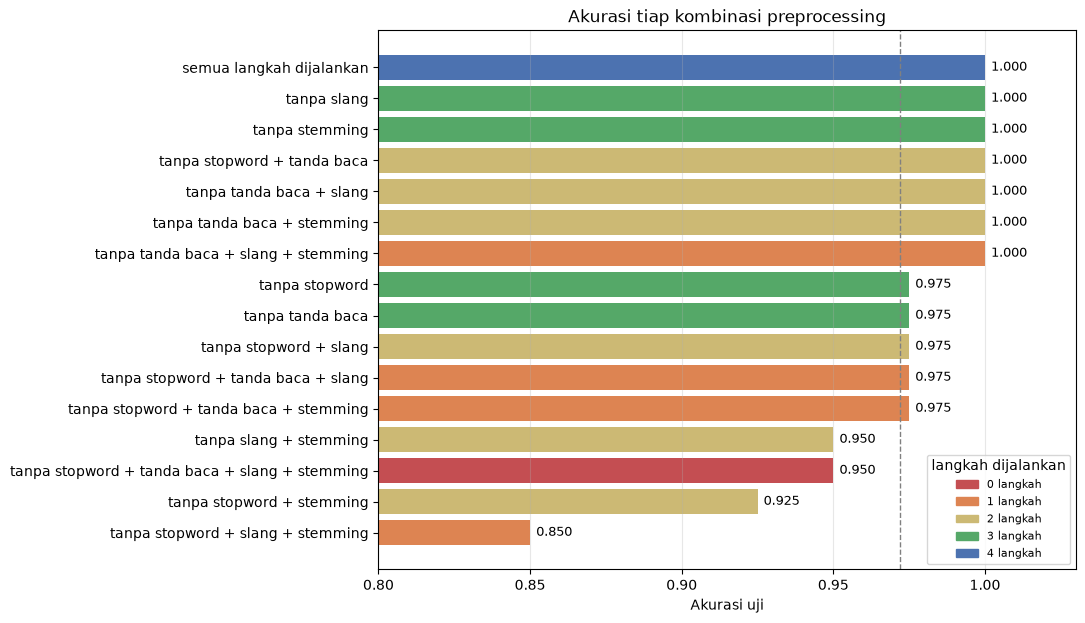

In [15]:
nama_sakelar = {
    "buang_stopword": "stopword",
    "buang_tanda_baca": "tanda baca",
    "normalisasi_slang": "slang",
    "stemming": "stemming",
}
kolom_sakelar = list(nama_sakelar)


def deskripsi(baris):
    off = [nama_sakelar[k] for k in kolom_sakelar if not baris[k]]
    return "semua langkah dijalankan" if not off else "tanpa " + " + ".join(off)


tampil = hasil.copy()
tampil["deskripsi"] = tampil.apply(deskripsi, axis=1)
tampil["aktif"] = tampil[kolom_sakelar].sum(axis=1)
tampil = tampil.sort_values(["akurasi", "aktif"]).reset_index(drop=True)

warna = {0: "#c44e52", 1: "#dd8452", 2: "#ccb974", 3: "#55a868", 4: "#4c72b0"}
plt.figure(figsize=(9, 7))
plt.barh(tampil["deskripsi"], tampil["akurasi"], color=[warna[n] for n in tampil["aktif"]])
plt.axvline(hasil["akurasi"].mean(), color="gray", linestyle="--", linewidth=1)
for y, v in enumerate(tampil["akurasi"]):
    plt.text(v + 0.002, y, f"{v:.3f}", va="center", fontsize=9)
plt.legend(handles=[Patch(color=warna[n], label=f"{n} langkah") for n in range(5)],
           title="langkah dijalankan", loc="lower right", fontsize=8)
plt.xlim(0.80, 1.03)
plt.xlabel("Akurasi uji")
plt.title("Akurasi tiap kombinasi preprocessing")
plt.grid(axis="x", alpha=0.3)
plt.show()

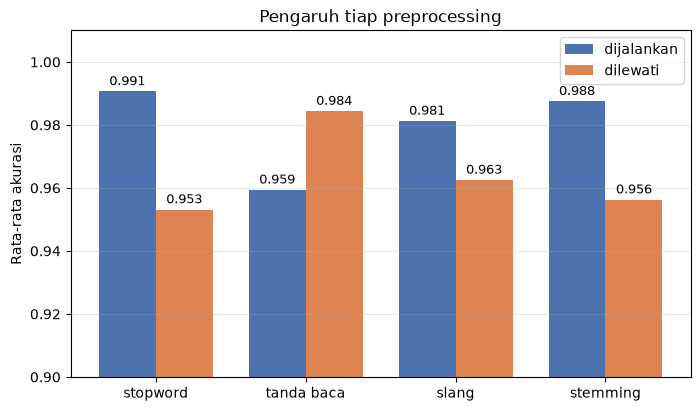

In [16]:
ringkas = pd.DataFrame([
    {
        "preprocessing": nama_sakelar[k],
        "dijalankan": hasil[hasil[k]]["akurasi"].mean(),
        "dilewati": hasil[~hasil[k]]["akurasi"].mean(),
    }
    for k in kolom_sakelar
])

x = np.arange(len(ringkas))
lebar = 0.38
plt.figure(figsize=(8, 4.5))
plt.bar(x - lebar / 2, ringkas["dijalankan"], lebar, label="dijalankan", color="#4c72b0")
plt.bar(x + lebar / 2, ringkas["dilewati"], lebar, label="dilewati", color="#dd8452")
for i, r in ringkas.iterrows():
    plt.text(i - lebar / 2, r["dijalankan"] + 0.002, f"{r['dijalankan']:.3f}", ha="center", fontsize=9)
    plt.text(i + lebar / 2, r["dilewati"] + 0.002, f"{r['dilewati']:.3f}", ha="center", fontsize=9)
plt.xticks(x, ringkas["preprocessing"])
plt.ylim(0.90, 1.01)
plt.ylabel("Rata-rata akurasi")
plt.title("Pengaruh tiap preprocessing")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

In [17]:
efek = ringkas.copy()
efek["selisih"] = (efek["dijalankan"] - efek["dilewati"]).round(3)
efek[["dijalankan", "dilewati"]] = efek[["dijalankan", "dilewati"]].round(3)
efek.sort_values("selisih", ascending=False).reset_index(drop=True)

,preprocessing,dijalankan,dilewati,selisih
0,stopword,0.991,0.953,0.038
1,stemming,0.988,0.956,0.031
2,slang,0.981,0.962,0.019
3,tanda baca,0.959,0.984,-0.025


## Model Comparison

Selain preprocessing, dua parameter `Word2Vec` paling menentukan di korpus sekecil ini:

| Parameter | Nilai | Peran |
|---|---|---|
| `sg` | 1 | 1 = skip-gram (menebak konteks dari kata pusat); 0 = CBOW (menebak kata dari konteksnya) |
| `window` | 2 | jari-jari kata tetangga yang dianggap konteks |
| `min_count` | 5 | kata berfrekuensi di bawah ini dibuang |
| `vector_size` | 100 | panjang vektor tiap kata |
| `workers` | 1 | satu utas bersama `seed` agar hasil dapat diulang |

Perbandingan berikut mengubah `sg` dan `window` sambil menahan parameter lain.

In [18]:
models = {}
baris_cmp = []
for sg, window in [(1, 2), (1, 5), (0, 2), (0, 5)]:
    token_latih = [prep(t) for t in X_train]
    mulai = time.time()
    model = Word2Vec(token_latih, vector_size=100, window=window, min_count=5, sg=sg, seed=42, workers=1)
    durasi = time.time() - mulai
    models[(sg, window)] = model
    A = np.array([doc_vector(prep(t), model) for t in X_train])
    B = np.array([doc_vector(prep(t), model) for t in X_test])
    clf = GaussianNB().fit(A, y_train)
    baris_cmp.append({
        "arsitektur": "skip-gram" if sg == 1 else "CBOW",
        "window": window,
        "kata unik": len(model.wv),
        "akurasi": round(accuracy_score(y_test, clf.predict(B)), 3),
        "waktu latih (s)": round(durasi, 2),
    })

model_cmp = pd.DataFrame(baris_cmp)
model_cmp

,arsitektur,window,kata unik,akurasi,waktu latih (s)
0,skip-gram,2,1783,0.975,0.85
1,skip-gram,5,1783,1.000,1.39
2,CBOW,2,1783,0.700,0.46
3,CBOW,5,1783,0.950,0.50


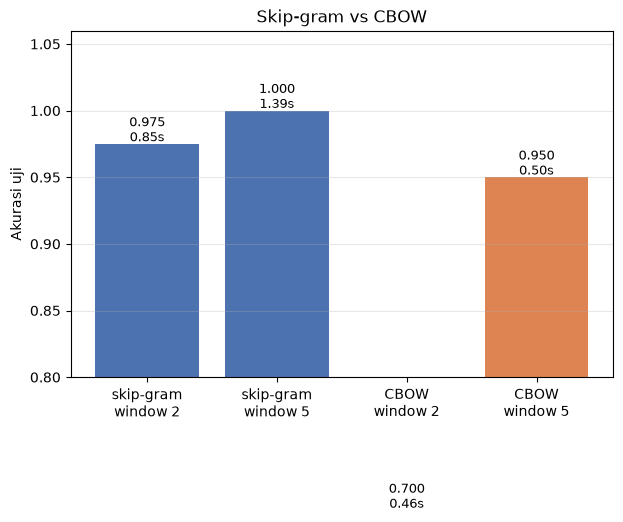

In [19]:
label = [f"{r.arsitektur}\nwindow {r.window}" for r in model_cmp.itertuples()]
warna = ["#4c72b0" if r.arsitektur == "skip-gram" else "#dd8452" for r in model_cmp.itertuples()]
plt.figure(figsize=(7, 4.5))
plt.bar(label, model_cmp["akurasi"], color=warna)
for i, r in model_cmp.iterrows():
    plt.text(i, r["akurasi"] + 0.002, f"{r['akurasi']:.3f}\n{r['waktu latih (s)']:.2f}s", ha="center", fontsize=9)
plt.ylim(0.80, 1.06)
plt.ylabel("Akurasi uji")
plt.title("Skip-gram vs CBOW")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [20]:
for kata in ["main", "saham"]:
    for sg in [1, 0]:
        model = models[(sg, 2)]
        if kata in model.wv:
            nama = "skip-gram" if sg == 1 else "CBOW"
            dekat = ", ".join(w for w, _ in model.wv.most_similar(kata, topn=5))
            print(f"{kata:<8} {nama:<9} -> {dekat}")

main     skip-gram -> klub, kompetisi, muda, latih, saing
main     CBOW      -> tanding, masuk, rupa, sekaligus, kompetisi
saham    skip-gram -> salur, lengkap, jamin, segera, workshop
saham    CBOW      -> lengkap, luas, dapat, sesuai, a


## Conclusion

Vektor skip-gram 100 dimensi yang dibangun langsung dari teks berita, tanpa
reduksi dimensi, sudah cukup memisahkan dua kelas yang secara leksikal memang
jauh berbeda. Kosakata olahraga dan istilah pasar modal terpisah sendiri tanpa
penandaan manual.

Keempat preprocessing berpengaruh, tetapi tidak seragam. Membuang stopword
rata-rata menaikkan akurasi (0,991 berbanding 0,953), begitu pula menerapkan
stemming (0,988 berbanding 0,956) dan membakukan slang (0,981 berbanding 0,963).
Membuang stopword paling membantu karena kata umum seperti `yang` dan `di`
muncul di kedua kelas sehingga tidak membedakan apa pun. Stemming memangkas kata
unik dari sekitar 2.120 menjadi 1.810. Tanda baca justru sebaliknya: membuangnya
menurunkan akurasi (0,959 berbanding 0,984), jadi lebih baik dipertahankan.

Dilihat per kombinasi, urutannya tidak lurus. Tujuh kombinasi menyentuh 1,000,
sedangkan yang paling rendah bukanlah tanpa semua langkah melainkan kombinasi
yang hanya membuang tanda baca (0,850); tanpa semua langkah sendiri berada di
0,950. Karena data uji hanya 40 berita, selisih satu-dua berita langsung
menggeser beberapa poin, sehingga urutan ini lebih menunjukkan arah daripada
peringkat yang pasti.

Perbandingan model menunjukkan skip-gram lebih cocok di korpus sekecil ini. Skip-gram bertahan pada 0,975-1,000, sedangkan CBOW jatuh ke 0,700 saat jendelanya sempit dan baru naik ke 0,950 setelah `window` dilebarkan menjadi 5. Jadi `window` paling menentukan untuk CBOW: dua kata konteks tidak cukup. Harga keunggulan skip-gram adalah waktu latih sekitar dua kali CBOW (0,85-1,39 detik berbanding 0,46-0,50 detik), tetapi selisih itu tidak berarti pada 160 dokumen latih. Dari kemiripan kata, tetangga skip-gram juga lebih rapat: di sekitar `main` muncul `klub`, `kompetisi`, `latih`, dan `saing`, sedangkan CBOW mencampurnya dengan kata yang tidak berhubungan seperti `rupa` dan `sekaligus`.